# Councillor Voting Alignment

Analyzes how councillors vote on each other's motions — revealing political alignment and voting blocs on Ottawa City Council.

## 1. Setup & DB Connection

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('../datasets/ottawa_city_scraper.duckdb', read_only=True)

# Quick sanity check
con.execute("SELECT COUNT(*) AS motions, COUNT(DISTINCT motion_moved_by) AS movers FROM motions WHERE motion_moved_by IS NOT NULL").df()

,motions,movers
0,6651,60


## 2. Alignment Query

For each (mover, voter) pair: what % of the mover's motions did the voter support?

In [6]:
alignment_df = con.execute("""
    SELECT
        m.motion_moved_by AS mover,
        v.councillor_name AS voter,
        COUNT(*) AS total_votes,
        SUM(CASE WHEN v.vote = 'for' THEN 1 ELSE 0 END) AS for_votes,
        ROUND(100.0 * SUM(CASE WHEN v.vote = 'for' THEN 1 ELSE 0 END) / COUNT(*), 1) AS support_pct
    FROM motions m
    JOIN votes v ON m.motion_id = v.motion_id
    WHERE m.motion_moved_by IS NOT NULL
      AND m.motion_moved_by != v.councillor_name
    GROUP BY m.motion_moved_by, v.councillor_name
    HAVING COUNT(*) >= 5
    ORDER BY mover, voter
""").df()

print(f"{len(alignment_df)} (mover, voter) pairs")
alignment_df.head(10)

343 (mover, voter) pairs


,mover,voter,total_votes,for_votes,support_pct
0,,A. Hubley,57,47.0,82.5
1,,A. Troster,79,47.0,59.5
2,,C. Curry,86,73.0,84.9
3,,C. Kelly,79,57.0,72.2
4,,C. Kitts,90,71.0,78.9
5,,D. Brown,71,50.0,70.4
6,,D. Hill,59,46.0,78.0
7,,G. Darouze,45,32.0,71.1
8,,G. Gower,93,80.0,86.0
9,,I. Skalski,24,21.0,87.5


## 3. Alignment Heatmap

Rows = voter, Columns = mover. Cell = % of mover's motions the voter supported.

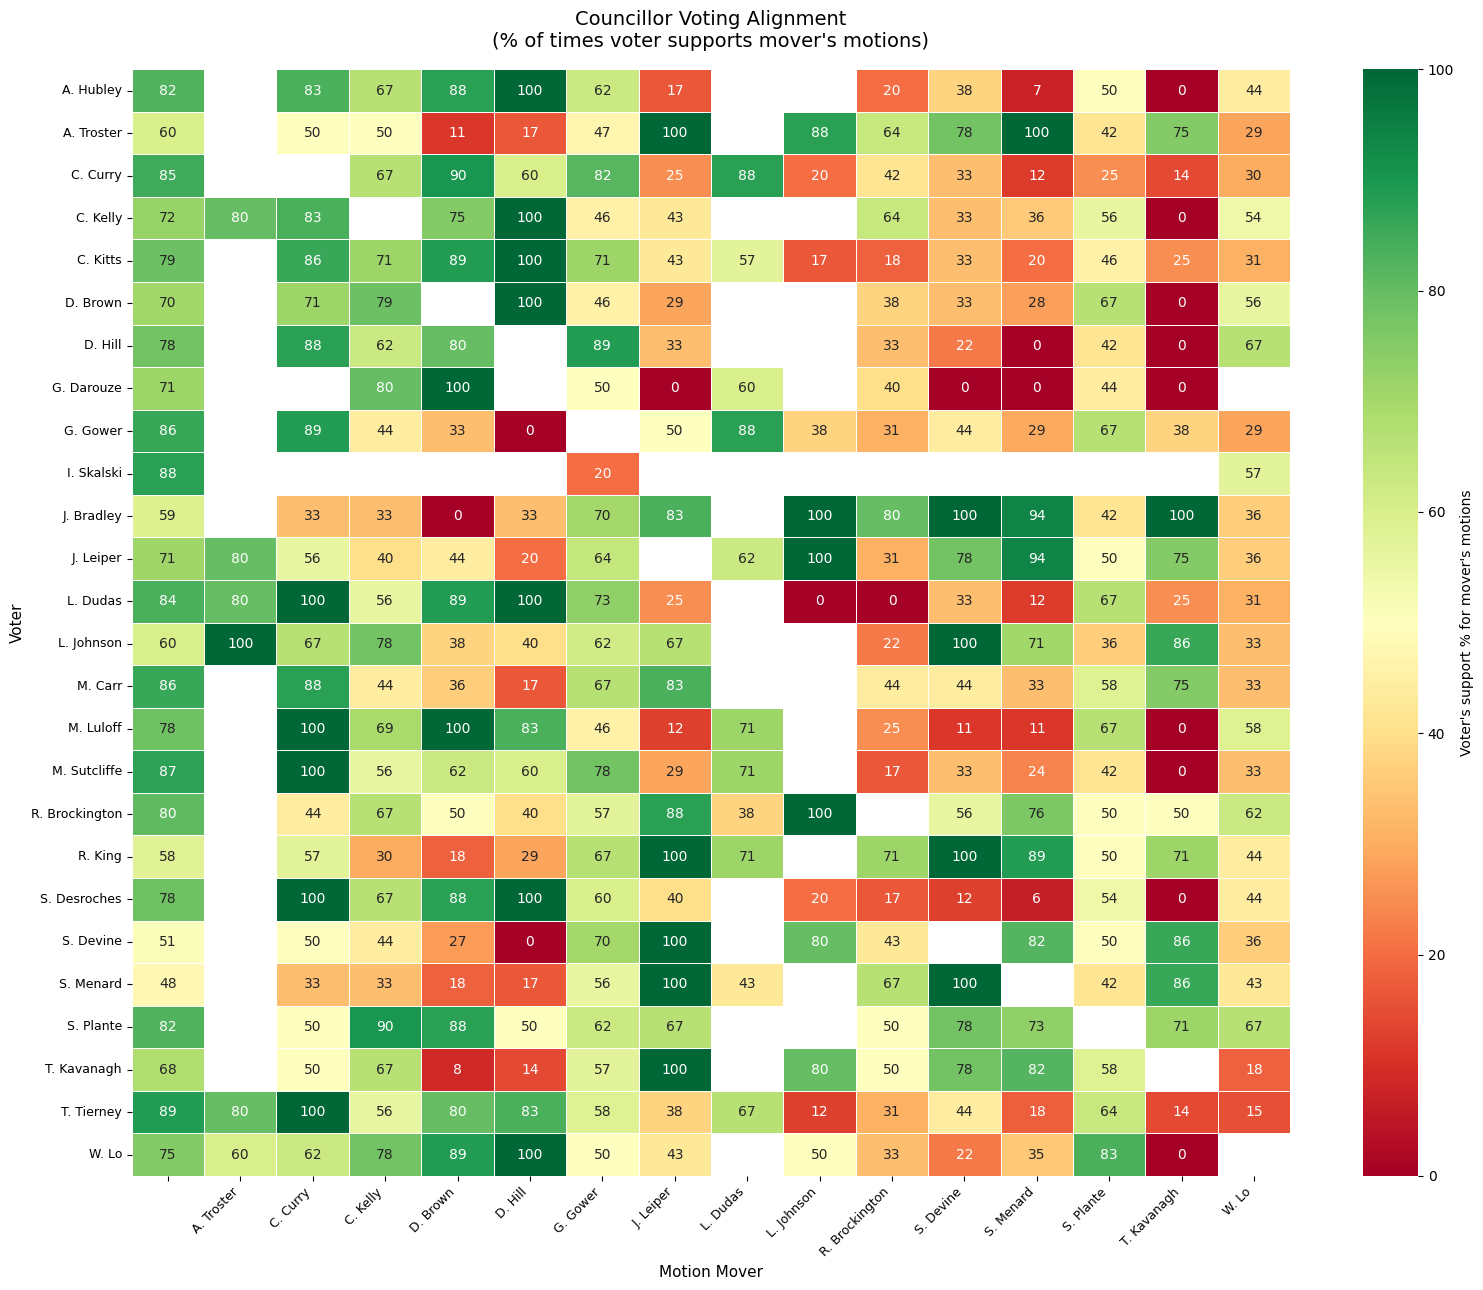

In [3]:
matrix = alignment_df.pivot(index='voter', columns='mover', values='support_pct')

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    matrix,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': "Voter's support % for mover's motions"}
)
ax.set_title("Councillor Voting Alignment\n(% of times voter supports mover's motions)", fontsize=14, pad=16)
ax.set_xlabel("Motion Mover", fontsize=11)
ax.set_ylabel("Voter", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Most & Least Aligned Pairs

In [4]:
ranked = alignment_df.sort_values('support_pct', ascending=False)

print("=== Top 10 Most Aligned (voter → mover) ===")
display(ranked.head(10)[['voter', 'mover', 'support_pct', 'for_votes', 'total_votes']].reset_index(drop=True))

print("\n=== Top 10 Least Aligned (voter → mover) ===")
display(ranked.tail(10)[['voter', 'mover', 'support_pct', 'for_votes', 'total_votes']].reset_index(drop=True))

=== Top 10 Most Aligned (voter → mover) ===


,voter,mover,support_pct,for_votes,total_votes
0,A. Troster,S. Menard,100.0,16.0,16
1,S. Desroches,C. Curry,100.0,5.0,5
2,T. Kavanagh,J. Leiper,100.0,7.0,7
3,D. Brown,D. Hill,100.0,7.0,7
4,J. Leiper,L. Johnson,100.0,5.0,5
5,C. Kitts,D. Hill,100.0,5.0,5
6,C. Kelly,D. Hill,100.0,5.0,5
7,M. Luloff,D. Brown,100.0,11.0,11
8,L. Johnson,A. Troster,100.0,5.0,5
9,S. Menard,J. Leiper,100.0,7.0,7



=== Top 10 Least Aligned (voter → mover) ===


,voter,mover,support_pct,for_votes,total_votes
0,L. Dudas,R. Brockington,0.0,0.0,8
1,A. Hubley,T. Kavanagh,0.0,0.0,8
2,D. Brown,T. Kavanagh,0.0,0.0,8
3,G. Darouze,S. Devine,0.0,0.0,5
4,W. Lo,T. Kavanagh,0.0,0.0,9
5,M. Luloff,T. Kavanagh,0.0,0.0,7
6,D. Hill,S. Menard,0.0,0.0,16
7,G. Darouze,S. Menard,0.0,0.0,14
8,C. Kelly,T. Kavanagh,0.0,0.0,7
9,M. Sutcliffe,T. Kavanagh,0.0,0.0,7


## 5. Seconder Alignment

Same analysis for `motion_seconded_by` — do seconders reliably vote for motions they seconded, and do others follow?

284 (seconder, voter) pairs


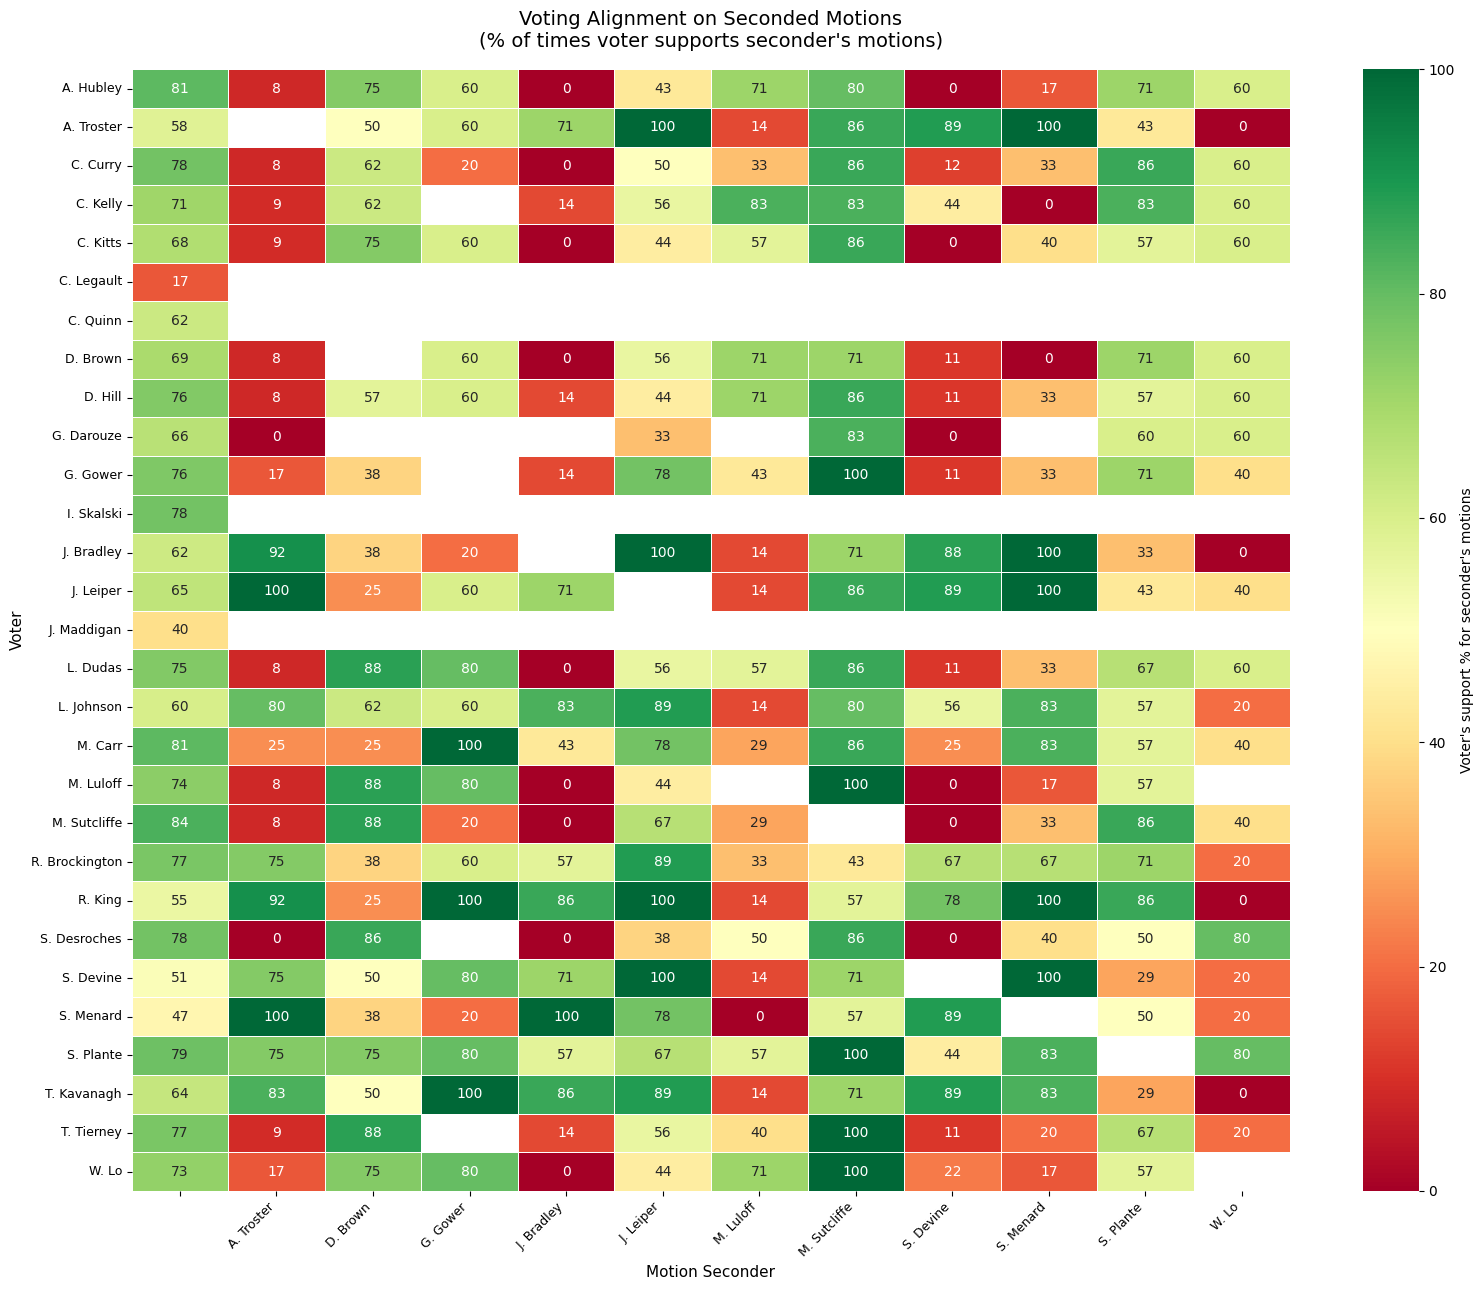

In [5]:
seconder_df = con.execute("""
    SELECT
        m.motion_seconded_by AS seconder,
        v.councillor_name AS voter,
        COUNT(*) AS total_votes,
        SUM(CASE WHEN v.vote = 'for' THEN 1 ELSE 0 END) AS for_votes,
        ROUND(100.0 * SUM(CASE WHEN v.vote = 'for' THEN 1 ELSE 0 END) / COUNT(*), 1) AS support_pct
    FROM motions m
    JOIN votes v ON m.motion_id = v.motion_id
    WHERE m.motion_seconded_by IS NOT NULL
      AND m.motion_seconded_by != v.councillor_name
    GROUP BY m.motion_seconded_by, v.councillor_name
    HAVING COUNT(*) >= 5
    ORDER BY seconder, voter
""").df()

print(f"{len(seconder_df)} (seconder, voter) pairs")

sec_matrix = seconder_df.pivot(index='voter', columns='seconder', values='support_pct')

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    sec_matrix,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': "Voter's support % for seconder's motions"}
)
ax.set_title("Voting Alignment on Seconded Motions\n(% of times voter supports seconder's motions)", fontsize=14, pad=16)
ax.set_xlabel("Motion Seconder", fontsize=11)
ax.set_ylabel("Voter", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Motion Pass Rate by Mover

For each councillor as mover: how many motions did they bring, and what % passed?

,mover,total_motions,carried,lost,pass_pct
0,A. E. Harvey,1,1.0,0.0,100.0
1,I. Eldahr,2,2.0,0.0,100.0
2,Member Elyse Banham,10,10.0,0.0,100.0
3,Member Danielle Brown-Shreves,2,2.0,0.0,100.0
4,Clara Freire,1,1.0,0.0,100.0
5,T. Cullen,2,2.0,0.0,100.0
6,C. Legault,1,1.0,0.0,100.0
7,Mireille Brownhill,1,1.0,0.0,100.0
8,F. Rivest,1,1.0,0.0,100.0
9,N. Bassett,1,1.0,0.0,100.0


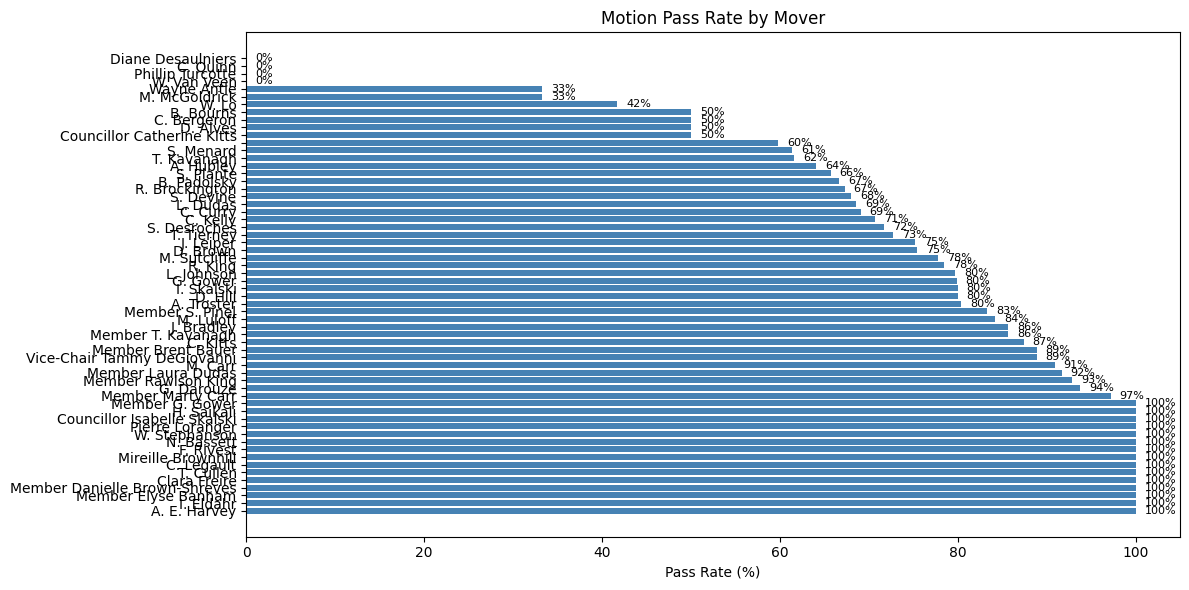

In [6]:
pass_rate_df = con.execute("""
    SELECT
        motion_moved_by AS mover,
        COUNT(*) AS total_motions,
        SUM(CASE WHEN LOWER(motion_result) = 'carried' THEN 1 ELSE 0 END) AS carried,
        SUM(CASE WHEN LOWER(motion_result) = 'lost' THEN 1 ELSE 0 END) AS lost,
        ROUND(100.0 * SUM(CASE WHEN LOWER(motion_result) = 'carried' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pass_pct
    FROM motions
    WHERE motion_moved_by IS NOT NULL
      AND motion_result IS NOT NULL
    GROUP BY motion_moved_by
    ORDER BY pass_pct DESC
""").df()

display(pass_rate_df)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(pass_rate_df['mover'], pass_rate_df['pass_pct'], color='steelblue')
ax.set_xlabel('Pass Rate (%)')
ax.set_title('Motion Pass Rate by Mover')
ax.set_xlim(0, 105)
for bar, val in zip(bars, pass_rate_df['pass_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()